#### Chain using LangGraph

##### Messages
- content : content of the message
- name : Specify the name of author
- response_metadata : optionally, a dict of metadata(eg :- often populated by model provider for AIMessages)

In [9]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.environ.get("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY")

In [10]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"Please tell me how can i help", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding", name="Dennis"))
messages.append(
    AIMessage(content=f"Which coding language do you want to learn", name="LLMModel")
)
messages.append(HumanMessage(content="python programming language", name="Dennis"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can i help
================================ Human Message =================================
Name: Dennis

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which coding language do you want to learn
================================ Human Message =================================
Name: Dennis

python programming language


##### Chat Models

In [11]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
response = llm.invoke(messages)
response

AIMessage(content='<think>\nOkay, the user wants to learn Python programming. Let me break down the steps they need to take. First, they need to install Python. I should mention the official website and maybe the version, like Python 3. Then they need an IDE or code editor. VS Code is popular, but they might not know about it. Maybe suggest Thonny for beginners because it\'s simple.\n\nNext, the basics. Start with variables and data types—int, float, string, boolean. Then operators: arithmetic, comparison, logical. Control structures like if-else, loops (for, while). Functions are important, so explain how to define them and parameters. Data structures: lists, tuples, dictionaries, sets. Maybe include list comprehensions as they\'re useful. Modules and packages—importing, using pip for third-party libraries.\n\nObject-Oriented Programming is a big one. Classes, objects, inheritance, encapsulation. File handling: reading and writing files. Exception handling with try-except. Libraries a

#### Tools
simple tool calling chatbot 

In [12]:
# simple function for adding two numbers
def add(a: int, b: int) -> int:
    """Add a and b
    Args:
        a(int): first int
        b(int): second int

        returns:
        int
    """
    return a + b

In [14]:
# binding llm with the tool

llm_with_tools = llm.bind_tools([add])
tool_call = llm_with_tools.invoke([HumanMessage(content=f"what is 2 plus 2", name="dennis")])
tool_call

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is 2 plus 2". Let me see. I need to figure out if I should use the add function provided. The function takes two integers, a and b, and returns their sum. The question is straightforward, adding 2 and 2. So, I should call the add function with a=2 and b=2. That should give the correct result. No other functions are available, so this is the right choice.\n', 'tool_calls': [{'id': 'qpancp0za', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 185, 'total_tokens': 311, 'completion_time': 0.211313973, 'completion_tokens_details': {'reasoning_tokens': 97}, 'prompt_time': 0.007726317, 'prompt_tokens_details': None, 'queue_time': 0.052049983, 'total_time': 0.21904029}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'tool_c

##### Note: as we can see there is no content from AI from the above output. but there is a output from the tool

In [16]:
# checking the tool response

tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'qpancp0za',
  'type': 'tool_call'}]

In [21]:
# providing messages as state

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [23]:
# creating a chatbot node
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

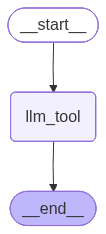

In [24]:
# configure the graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
messages = graph.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (tyj3xckre)
 Call ID: tyj3xckre
  Args:
    a: 2
    b: 2


##### Example for how reducers work

In [18]:
initial_messasges = [AIMessage(content=f"please tell me how can i help", name="LLMModel")]
initial_messasges.append(HumanMessage(content=f"I want to learn coding", name="Dennis"))
initial_messasges

[AIMessage(content='please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Dennis')]

In [19]:
ai_messasges=(AIMessage(content=f"What language do you want to learn", name="LLMModel"))
ai_messasges

AIMessage(content='What language do you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [22]:
add_messages(initial_messasges, ai_messasges)

[AIMessage(content='please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='d7f6600b-7ff6-4bb6-b1ce-e3a97c7ff302', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Dennis', id='196c85b0-fd0f-481d-901f-c1076f8071de'),
 AIMessage(content='What language do you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='64c22833-56a3-43c1-9aed-d81dd05fff65', tool_calls=[], invalid_tool_calls=[])]